# Solar Flare Detection & Classification — Training Notebook

Trains and evaluates **two models** on the windowed SoLEXS feature table produced by
`build_flare_dataset.py`:

1. **Part A — Flare Detection (binary)**: `label_binary`. This is the primary model.
2. **Part B — Flare Classification (A/B/C/M/X)**: `label_class`, trained only on windows
   already flagged as flares (Part A's positives), matching the two-stage
   detect-then-classify design.

Both parts train a **RandomForestClassifier** and a **HistGradientBoostingClassifier**
(sklearn's fast histogram-based GBM — the classic `GradientBoostingClassifier` does not
scale to multi-million-row datasets like this one), tuned with `GridSearchCV`, with class
imbalance handled via `class_weight='balanced'` / `sample_weight`.

**HEK data is never used past labeling** — it was only used to build `label_binary` /
`label_class` in the previous pipeline step. No HEK-derived column exists in this table's
feature set; nothing here needs HEK again.

**Chronological split**: because windows overlap (60s window / 15s stride) and are
grouped into contiguous `segment_id`s, a naive random split would leak the same flare's
neighboring windows into both train and test. The split below assigns **whole segments**
to train/val/test in chronological order, so no segment (and therefore no single flare
event) is ever split across sets.


## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Config — edit these paths/values for your run

In [2]:
DATA_PATH = r"data\out_builddata\windows_features.parquet"   # <-- output of build_flare_dataset.py
OUT_DIR = r"lastrun\model_output"                 # where trained models/metrics get saved

TRAIN_FRAC = 0.70   # fraction of windows (by chronological segment order) -> train
VAL_FRAC = 0.15      # -> validation (threshold tuning). remainder -> test (final report)

TARGET_RECALL = 0.90            # detection model must catch >=95% of true flares
GRID_SEARCH_MAX_ROWS = 150_000  # cap rows used *during hyperparameter search* for speed;
                                 # the best params are then refit on the FULL training set.

import os
os.makedirs(OUT_DIR, exist_ok=True)


## 2. Load data & select features

Columns from the pipeline fall into three groups:
- **Identifiers / bookkeeping** (`window_start_time`, `window_end_time`, `segment_id`,
  `source_file`): needed for splitting and traceability, but not fed to the model.
- **Label-derived** (`label_binary`, `label_class`, `flare_frac_in_window`): these come
  from HEK and are targets, not features — `flare_frac_in_window` in particular is a
  near-perfect proxy for the label itself and would leak if included as a feature.
- **Everything else**: the actual engineered features (counts stats, background-relative
  features, cyclic time features).


In [ ]:
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(f"Date range: {df.window_start_time.min()} -> {df.window_start_time.max()}")

NON_FEATURE_COLS = [
    "window_start_time", "window_end_time", "segment_id", "source_file",
    "label_binary", "label_class", "flare_frac_in_window",
]
FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURE_COLS]
print(f"\n{len(FEATURE_COLS)} feature columns:")
print(FEATURE_COLS)

n_inf = np.isinf(df[FEATURE_COLS].to_numpy(dtype="float64")).sum()
df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
print(f"\nReplaced {n_inf} inf values with NaN")

nan_report = df[FEATURE_COLS].isna().sum()
nan_report = nan_report[nan_report > 0]
print("\nRemaining NaNs by column (mostly early-segment background warm-up):")
print(nan_report if len(nan_report) else "  (none)")

print("\nlabel_binary balance:")
print(df["label_binary"].value_counts(normalize=True))
print("\nlabel_class balance:")
print(df["label_class"].value_counts())


Loaded 1,882,974 rows, 33 columns
Date range: 2024-02-02 00:00:00 -> 2026-06-21 23:59:00

26 feature columns:
['n_valid', 'frac_valid', 'mean', 'median', 'std', 'min', 'max', 'ptp', 'p25', 'p75', 'p90', 'skew', 'kurtosis', 'slope', 'rise_delta', 'bg_median_at_end', 'bg_mad_std_at_end', 'mean_excess', 'max_sigma_excess', 'mean_ratio_to_bg', 'max_ratio_to_bg', 'frac_above_3sigma', 'frac_above_5sigma', 'ratio_local_to_longterm_bg', 'hour_sin', 'hour_cos']

Replaced 188 inf values with NaN

Remaining NaNs by column (mostly early-segment background warm-up):
skew                             22
kurtosis                         33
slope                            22
rise_delta                      475
bg_median_at_end                507
bg_mad_std_at_end             17923
mean_excess                     507
max_sigma_excess              17736
mean_ratio_to_bg                637
max_ratio_to_bg                 637
ratio_local_to_longterm_bg    78313
dtype: int64

label_binary balance:
label_bi

## 3. Chronological, segment-aware train / val / test split

Segments are already sorted by construction; we order them by their first timestamp and
assign whole segments to train/val/test by cumulative row count, so the split stays close
to the requested fractions while never breaking a segment (and therefore never breaking a
flare) across sets. Validation is used later for threshold tuning; test is only touched
once, at the end, for the final reported numbers.


In [4]:
def segment_chronological_split(data, train_frac, val_frac):
    seg_order = (data.groupby("segment_id")["window_start_time"].min()
                 .sort_values().index.tolist())
    seg_sizes = data["segment_id"].value_counts()
    total = len(data)
    cum = 0
    train_segs, val_segs, test_segs = [], [], []
    for sid in seg_order:
        cum += seg_sizes[sid]
        frac = cum / total
        if frac <= train_frac:
            train_segs.append(sid)
        elif frac <= train_frac + val_frac:
            val_segs.append(sid)
        else:
            test_segs.append(sid)
    return train_segs, val_segs, test_segs


train_segs, val_segs, test_segs = segment_chronological_split(df, TRAIN_FRAC, VAL_FRAC)

train_df = df[df.segment_id.isin(train_segs)].copy()
val_df = df[df.segment_id.isin(val_segs)].copy()
test_df = df[df.segment_id.isin(test_segs)].copy()

print(f"train: {len(train_df):,} rows ({train_df.window_start_time.min()} -> {train_df.window_start_time.max()})")
print(f"val:   {len(val_df):,} rows ({val_df.window_start_time.min()} -> {val_df.window_start_time.max()})")
print(f"test:  {len(test_df):,} rows ({test_df.window_start_time.min()} -> {test_df.window_start_time.max()})")

print("\nPositive rate  train/val/test:",
      round(train_df.label_binary.mean(), 4),
      round(val_df.label_binary.mean(), 4),
      round(test_df.label_binary.mean(), 4))

print("\nRare-class coverage check (want at least a handful of X/B in each split):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"  {name}: {d.label_class.value_counts().to_dict()}")


train: 1,316,967 rows (2024-02-02 00:00:00 -> 2025-08-04 23:59:00)
val:   266,567 rows (2025-08-06 00:00:00 -> 2025-12-08 23:59:00)
test:  299,440 rows (2025-12-10 00:00:00 -> 2026-06-21 23:59:00)

Positive rate  train/val/test: 0.1524 0.1439 0.1337

Rare-class coverage check (want at least a handful of X/B in each split):
  train: {'NONE': 1116248, 'C': 130173, 'M': 63660, 'X': 5548, 'B': 1338}
  val: {'NONE': 228219, 'C': 29763, 'M': 6730, 'B': 1223, 'X': 632}
  test: {'NONE': 259417, 'C': 31309, 'M': 6191, 'B': 2291, 'X': 232}


## 4. Preprocessing

Tree-based models don't need feature scaling, but `RandomForestClassifier` (unlike
`HistGradientBoostingClassifier`) can't handle NaNs natively, so we median-impute — fit
strictly on train, applied unchanged to val/test to avoid leakage.

**Note on pandas/pyarrow**: recent pandas versions can back parquet-loaded columns with
Arrow arrays, which breaks scikit-learn's fancy indexing during cross-validation on
non-numeric columns. We convert label/group arrays with `.to_numpy()` explicitly below to
avoid this.


In [5]:
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(train_df[FEATURE_COLS])
X_val = imputer.transform(val_df[FEATURE_COLS])
X_test = imputer.transform(test_df[FEATURE_COLS])

y_train = train_df["label_binary"].to_numpy()
y_val = val_df["label_binary"].to_numpy()
y_test = test_df["label_binary"].to_numpy()

groups_train = train_df["segment_id"].to_numpy()

sample_weight_train = compute_sample_weight("balanced", y_train)
print("Effective class weights (balanced):",
      dict(zip(*np.unique(y_train, return_counts=True))))


Effective class weights (balanced): {np.int64(0): np.int64(1116248), np.int64(1): np.int64(200719)}


## 5. Part A — Flare Detection (binary): hyperparameter search

`GridSearchCV` uses `GroupKFold` on `segment_id` (not plain K-Fold) so that overlapping
windows from the same segment never end up split across CV train/val folds — plain
K-Fold would let near-duplicate neighboring windows leak across folds and give an
over-optimistic CV score.

For speed, the search itself runs on a **stratified-by-segment subsample** capped at
`GRID_SEARCH_MAX_ROWS`; once the best hyperparameters are found, both models are refit on
the **full** training set with `sample_weight`/`class_weight` applied.


In [6]:
def make_search_subsample(train_df, train_segs, max_rows, seed=RANDOM_STATE):
    n_total = len(train_df)
    if n_total <= max_rows:
        return np.arange(n_total)
    rng = np.random.default_rng(seed)
    frac = max_rows / n_total
    idx_parts = []
    for sid in train_segs:
        seg_rows = np.where(train_df["segment_id"].to_numpy() == sid)[0]
        n_keep = max(1, int(round(len(seg_rows) * frac)))
        idx_parts.append(rng.choice(seg_rows, size=min(n_keep, len(seg_rows)), replace=False))
    return np.concatenate(idx_parts)


sub_idx = make_search_subsample(train_df, train_segs, GRID_SEARCH_MAX_ROWS)
X_search, y_search = X_train[sub_idx], y_train[sub_idx]
sw_search = sample_weight_train[sub_idx]
groups_search = groups_train[sub_idx]

n_groups = len(np.unique(groups_search))
n_splits = min(4, n_groups)
cv_splits = list(GroupKFold(n_splits=n_splits).split(X_search, y_search, groups_search))
print(f"Grid-search subsample: {len(X_search):,} rows, {n_groups} segments, {n_splits}-fold GroupKFold")


Grid-search subsample: 150,015 rows, 81 segments, 4-fold GroupKFold


In [7]:
%%time
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 5],
}
rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced")
rf_search = GridSearchCV(rf_base, rf_param_grid, scoring="f1", cv=cv_splits,
                          n_jobs=-1, refit=False)
rf_search.fit(X_search, y_search)
print("RF best params:", rf_search.best_params_)
print("RF best CV F1:", round(rf_search.best_score_, 4))


RF best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 400}
RF best CV F1: 0.66
CPU times: total: 10.9 s
Wall time: 47min 41s


In [8]:
%%time
hgb_param_grid = {
    "max_iter": [150, 300],
    "max_depth": [None, 10],
    "learning_rate": [0.05, 0.1],
}
hgb_base = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
hgb_search = GridSearchCV(hgb_base, hgb_param_grid, scoring="f1", cv=cv_splits,
                           n_jobs=-1, refit=False)
hgb_search.fit(X_search, y_search, sample_weight=sw_search)
print("HistGB best params:", hgb_search.best_params_)
print("HistGB best CV F1:", round(hgb_search.best_score_, 4))


HistGB best params: {'learning_rate': 0.05, 'max_depth': None, 'max_iter': 150}
HistGB best CV F1: 0.8129
CPU times: total: 1.19 s
Wall time: 2min 45s


### 5b. Refit best hyperparameters on the FULL training set

In [9]:
%%time
best_rf = RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_STATE,
                                  n_jobs=-1, class_weight="balanced")
best_rf.fit(X_train, y_train)

best_hgb = HistGradientBoostingClassifier(**hgb_search.best_params_, random_state=RANDOM_STATE)
best_hgb.fit(X_train, y_train, sample_weight=sample_weight_train)

detection_models = {"RandomForest": best_rf, "HistGB": best_hgb}
print("Both models refit on full training set.")


Both models refit on full training set.
CPU times: total: 1h 40min 32s
Wall time: 30min


## 6. Threshold tuning on validation set

Default `predict()` uses a 0.5 cutoff, which is arbitrary once class weighting shifts the
decision boundary. Instead: sweep the probability threshold on the **validation** set,
and pick the threshold that **maximizes F1 subject to recall >= TARGET_RECALL**. If that
recall target isn't reachable at any threshold, fall back to the highest-recall threshold
available and warn loudly — that means the model itself (not just the cutoff) needs more
work, e.g. more/better features or more positive examples.


In [10]:
def choose_threshold(y_true, proba, target_recall):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1s = 2 * precision * recall / (precision + recall + 1e-12)
    # precision_recall_curve returns len(thresholds) == len(precision) - 1
    precision, recall, f1s = precision[:-1], recall[:-1], f1s[:-1]

    feasible = recall >= target_recall
    if feasible.any():
        best_i = np.argmax(np.where(feasible, f1s, -1))
        reachable = True
    else:
        best_i = np.argmax(recall)
        reachable = False
    return thresholds[best_i], reachable, precision[best_i], recall[best_i], f1s[best_i]


thresholds = {}
for name, model in detection_models.items():
    val_proba = model.predict_proba(X_val)[:, 1]
    thr, reachable, p, r, f1 = choose_threshold(y_val, val_proba, TARGET_RECALL)
    thresholds[name] = thr
    status = "OK" if reachable else f"NOT REACHABLE at any threshold -- using best available recall"
    print(f"[{name}] threshold={thr:.4f}  val precision={p:.3f}  val recall={r:.3f}  val F1={f1:.3f}  ({status})")


[RandomForest] threshold=0.0827  val precision=0.273  val recall=0.900  val F1=0.419  (OK)
[HistGB] threshold=0.1857  val precision=0.277  val recall=0.900  val F1=0.424  (OK)


## 7. Final evaluation on the held-out test set

In [11]:
test_results = {}
for name, model in detection_models.items():
    thr = thresholds[name]
    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= thr).astype(int)

    print(f"\n{'='*60}\n{name}  (threshold={thr:.4f})\n{'='*60}")
    print(classification_report(y_test, test_pred, digits=3, target_names=["no_flare", "flare"]))
    roc_auc = roc_auc_score(y_test, test_proba)
    pr_auc = average_precision_score(y_test, test_proba)
    print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}")

    test_results[name] = dict(
        threshold=float(thr),
        recall=float(recall_score(y_test, test_pred)),
        precision=float(precision_score(y_test, test_pred)),
        f1=float(f1_score(y_test, test_pred)),
        roc_auc=float(roc_auc),
        pr_auc=float(pr_auc),
    )

pd.DataFrame(test_results).T



RandomForest  (threshold=0.0827)
              precision    recall  f1-score   support

    no_flare      0.972     0.596     0.739    259417
       flare      0.254     0.890     0.395     40023

    accuracy                          0.635    299440
   macro avg      0.613     0.743     0.567    299440
weighted avg      0.876     0.635     0.693    299440

ROC-AUC: 0.8777   PR-AUC: 0.7054

HistGB  (threshold=0.1857)
              precision    recall  f1-score   support

    no_flare      0.973     0.620     0.758    259417
       flare      0.265     0.889     0.409     40023

    accuracy                          0.656    299440
   macro avg      0.619     0.755     0.583    299440
weighted avg      0.879     0.656     0.711    299440

ROC-AUC: 0.8832   PR-AUC: 0.7124


,threshold,recall,precision,f1,roc_auc,pr_auc
RandomForest,0.082728,0.889763,0.253502,0.394584,0.877687,0.705426
HistGB,0.185680,0.889164,0.265305,0.408673,0.883206,0.712351


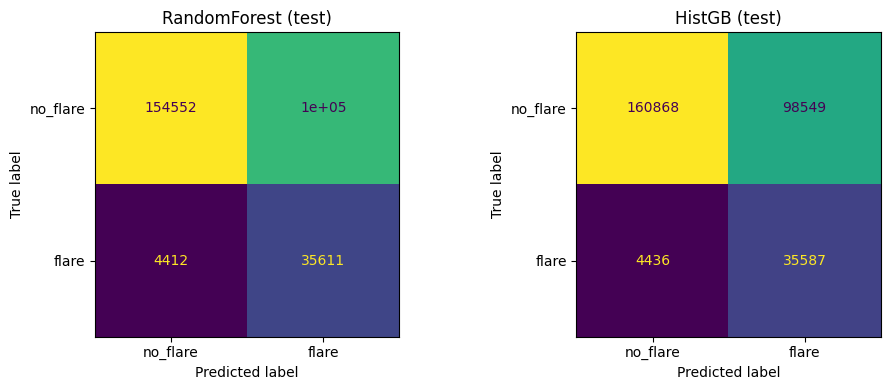

In [12]:
fig, axes = plt.subplots(1, len(detection_models), figsize=(5 * len(detection_models), 4))
if len(detection_models) == 1:
    axes = [axes]
for ax, (name, model) in zip(axes, detection_models.items()):
    thr = thresholds[name]
    test_pred = (model.predict_proba(X_test)[:, 1] >= thr).astype(int)
    cm = confusion_matrix(y_test, test_pred)
    ConfusionMatrixDisplay(cm, display_labels=["no_flare", "flare"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} (test)")
plt.tight_layout()
plt.show()


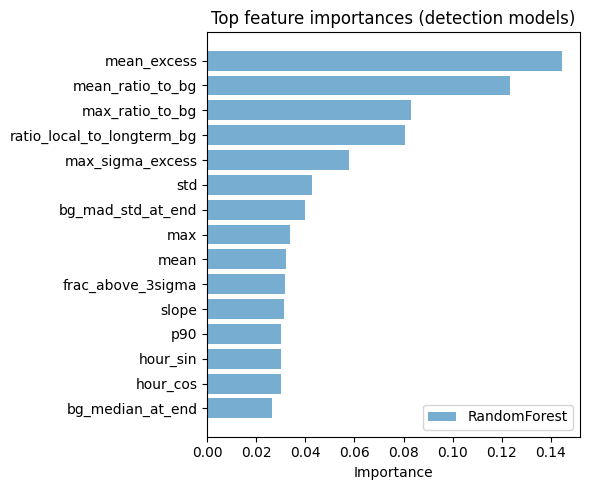

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in detection_models.items():
    importances = getattr(model, "feature_importances_", None)
    if importances is None:
        continue
    order = np.argsort(importances)[::-1][:15]
    ax.barh([FEATURE_COLS[i] for i in order][::-1], importances[order][::-1],
            alpha=0.6, label=name)
ax.set_xlabel("Importance")
ax.set_title("Top feature importances (detection models)")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Pick the winning detection model & save it

Selection rule: among models that reach `TARGET_RECALL` on validation, take the one with
the highest test F1. If neither reaches the recall target, pick whichever has the higher
recall (recall is the hard requirement for this detector) and flag it for follow-up.


In [22]:
reachable_models = {n: v for n, v in test_results.items() if v["recall"] >= TARGET_RECALL}
if reachable_models:
    winner = max(reachable_models, key=lambda n: reachable_models[n]["f1"])
else:
    winner = max(test_results, key=lambda n: test_results[n]["f1"])
    print(f"Selecting '{winner}' as the best available -- revisit features/data before deploying.")

print(f"Selected detection model: {winner}")
print(test_results[winner])

joblib.dump(detection_models[winner], f"{OUT_DIR}/detection_model.joblib")
joblib.dump(imputer, f"{OUT_DIR}/detection_imputer.joblib")
with open(f"{OUT_DIR}/detection_meta.json", "w") as f:
    json.dump({
        "model_name": winner,
        "threshold": thresholds[winner],
        "feature_cols": FEATURE_COLS,
        "test_metrics": test_results[winner],
    }, f, indent=2)
print(f"Saved to {OUT_DIR}/detection_model.joblib (+ imputer + meta.json)")


Selecting 'HistGB' as the best available -- revisit features/data before deploying.
Selected detection model: HistGB
{'threshold': 0.18568004077194514, 'recall': 0.8891637308547585, 'precision': 0.26530536172243097, 'f1': 0.40867253486756355, 'roc_auc': 0.8832060134791502, 'pr_auc': 0.7123514993909261}
Saved to lastrun\model_output/detection_model.joblib (+ imputer + meta.json)


---
## 9. Part B — Flare Classification (A/B/C/M/X)

Trained only on windows already labeled as flares (`label_binary == 1`), mirroring the
two-stage detect-then-classify design: this model only ever sees candidates the detector
already flagged. Same chronological/segment-aware split logic, same imbalance handling,
same GridSearchCV-with-GroupKFold approach — optimized for **weighted F1** since class
sizes differ hugely (C >> M >> X > B in this dataset).


In [15]:
pos_df = df[df.label_binary == 1].copy()
print(f"Positive-only rows for classification: {len(pos_df):,}")
print(pos_df.label_class.value_counts())

c_train_segs, c_val_segs, c_test_segs = segment_chronological_split(pos_df, TRAIN_FRAC, VAL_FRAC)
c_train_df = pos_df[pos_df.segment_id.isin(c_train_segs)].copy()
c_val_df = pos_df[pos_df.segment_id.isin(c_val_segs)].copy()
c_test_df = pos_df[pos_df.segment_id.isin(c_test_segs)].copy()
print(f"train/val/test: {len(c_train_df)}/{len(c_val_df)}/{len(c_test_df)}")

for name, d in [("train", c_train_df), ("val", c_val_df), ("test", c_test_df)]:
    print(f"  {name}: {d.label_class.value_counts().to_dict()}")


Positive-only rows for classification: 279,090
label_class
C    191245
M     76581
X      6412
B      4852
Name: count, dtype: int64
train/val/test: 193647/42296/43147
  train: {'C': 123267, 'M': 63494, 'X': 5548, 'B': 1338}
  val: {'C': 34467, 'M': 6038, 'B': 1223, 'X': 568}
  test: {'C': 33511, 'M': 7049, 'B': 2291, 'X': 296}


In [16]:
class_imputer = SimpleImputer(strategy="median")
Xc_train = class_imputer.fit_transform(c_train_df[FEATURE_COLS])
Xc_val = class_imputer.transform(c_val_df[FEATURE_COLS])
Xc_test = class_imputer.transform(c_test_df[FEATURE_COLS])

# .to_numpy() is important here: parquet-loaded string columns can be pyarrow-backed,
# which breaks sklearn's fancy indexing during GroupKFold cross-validation otherwise.
yc_train = c_train_df["label_class"].astype(str).to_numpy()
yc_val = c_val_df["label_class"].astype(str).to_numpy()
yc_test = c_test_df["label_class"].astype(str).to_numpy()
groups_c_train = c_train_df["segment_id"].to_numpy()

sw_c_train = compute_sample_weight("balanced", yc_train)

c_sub_idx = make_search_subsample(c_train_df, c_train_segs, GRID_SEARCH_MAX_ROWS)
Xc_search, yc_search = Xc_train[c_sub_idx], yc_train[c_sub_idx]
swc_search = sw_c_train[c_sub_idx]
groups_c_search = groups_c_train[c_sub_idx]

nc_groups = len(np.unique(groups_c_search))
nc_splits = min(4, nc_groups)
cv_c_splits = list(GroupKFold(n_splits=nc_splits).split(Xc_search, yc_search, groups_c_search))
print(f"Classification grid-search subsample: {len(Xc_search):,} rows, {nc_groups} segments, {nc_splits}-fold")


Classification grid-search subsample: 149,998 rows, 77 segments, 4-fold


In [17]:
%%time
rf_c_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight="balanced"),
    rf_param_grid, scoring="f1_weighted", cv=cv_c_splits, n_jobs=-1, refit=False,
)
rf_c_search.fit(Xc_search, yc_search)
print("RF (classification) best params:", rf_c_search.best_params_)
print("RF (classification) best CV weighted-F1:", round(rf_c_search.best_score_, 4))


RF (classification) best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
RF (classification) best CV weighted-F1: 0.8555
CPU times: total: 7.64 s
Wall time: 36min 29s


In [18]:
%%time
hgb_c_search = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    hgb_param_grid, scoring="f1_weighted", cv=cv_c_splits, n_jobs=-1, refit=False,
)
hgb_c_search.fit(Xc_search, yc_search, sample_weight=swc_search)
print("HistGB (classification) best params:", hgb_c_search.best_params_)
print("HistGB (classification) best CV weighted-F1:", round(hgb_c_search.best_score_, 4))


HistGB (classification) best params: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 150}
HistGB (classification) best CV weighted-F1: 0.6831
CPU times: total: 1.64 s
Wall time: 7min 4s


In [19]:
%%time
best_rf_c = RandomForestClassifier(**rf_c_search.best_params_, random_state=RANDOM_STATE,
                                    n_jobs=-1, class_weight="balanced")
best_rf_c.fit(Xc_train, yc_train)

best_hgb_c = HistGradientBoostingClassifier(**hgb_c_search.best_params_, random_state=RANDOM_STATE)
best_hgb_c.fit(Xc_train, yc_train, sample_weight=sw_c_train)

classification_models = {"RandomForest": best_rf_c, "HistGB": best_hgb_c}

class_test_results = {}
for name, model in classification_models.items():
    pred = model.predict(Xc_test)
    wf1 = f1_score(yc_test, pred, average="weighted")
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(yc_test, pred, digits=3, zero_division=0))
    class_test_results[name] = wf1

class_winner = max(class_test_results, key=class_test_results.get)
print(f"\nSelected classification model: {class_winner} (weighted F1={class_test_results[class_winner]:.3f})")



RandomForest
              precision    recall  f1-score   support

           B      0.439     0.344     0.386      2291
           C      0.886     0.965     0.923     33511
           M      0.921     0.620     0.741      7049
           X      1.000     0.318     0.482       296

    accuracy                          0.871     43147
   macro avg      0.811     0.562     0.633     43147
weighted avg      0.868     0.871     0.862     43147


HistGB
              precision    recall  f1-score   support

           B      0.431     0.387     0.408      2291
           C      0.887     0.949     0.917     33511
           M      0.855     0.623     0.721      7049
           X      0.922     0.240     0.381       296

    accuracy                          0.861     43147
   macro avg      0.774     0.550     0.607     43147
weighted avg      0.858     0.861     0.854     43147


Selected classification model: RandomForest (weighted F1=0.862)
CPU times: total: 13min 30s
Wall time: 3min

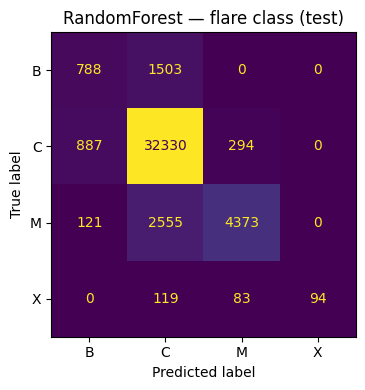

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
labels_order = ["B", "C", "M", "X"]
cm = confusion_matrix(yc_test, classification_models[class_winner].predict(Xc_test), labels=labels_order)
ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, colorbar=False)
ax.set_title(f"{class_winner} — flare class (test)")
plt.tight_layout()
plt.show()


In [21]:
joblib.dump(classification_models[class_winner], f"{OUT_DIR}/classification_model.joblib")
joblib.dump(class_imputer, f"{OUT_DIR}/classification_imputer.joblib")
with open(f"{OUT_DIR}/classification_meta.json", "w") as f:
    json.dump({
        "model_name": class_winner,
        "feature_cols": FEATURE_COLS,
        "weighted_f1_test": class_test_results[class_winner],
    }, f, indent=2)
print(f"Saved to {OUT_DIR}/classification_model.joblib (+ imputer + meta.json)")


Saved to lastrun\model_output/classification_model.joblib (+ imputer + meta.json)


## 10. Summary

- **Detection model** (`detection_model.joblib`): binary flare/no-flare,threshold and metadata saved alongside it.
- **Classification model** (`classification_model.joblib`): A/B/C/M/X, trained only on
  true positives, weighted-F1 optimized.
- Both use the **same `FEATURE_COLS`**, so at inference time: run the detection model
  first; only if it fires, run the classification model on that same window's features.
- Since all background/statistics features in this pipeline were computed **causally**
  (trailing-only, no look-ahead), the exact same feature-engineering code from
  `build_flare_dataset.py` can be reused unmodified in a real-time streaming loop.